In [1]:
import pandas as pd

In [2]:
dat=pd.read_csv('/home/maria/CrimeStats/data/creditcard.csv')

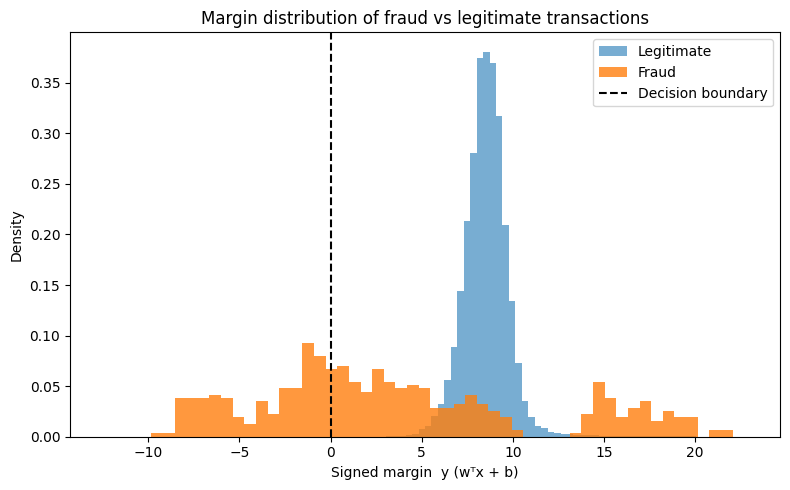

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Load data
# -----------------------------

dat = pd.read_csv('/home/maria/CrimeStats/data/creditcard.csv')

X = dat.drop(columns=['Class']).values
y = dat['Class'].values

# convert labels to {-1,1}
y_signed = np.where(y == 1, 1, -1)

# -----------------------------
# Standardize features
# -----------------------------

scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------------
# Fit logistic regression
# (no train/test split)
# -----------------------------

model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

model.fit(X, y)

# -----------------------------
# Decision scores
# -----------------------------

scores = model.decision_function(X)

# signed margin
margins = y_signed * scores

# separate groups
fraud_margins = margins[y == 1]
legit_margins = margins[y == 0]

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8,5))

plt.hist(
    legit_margins,
    bins=100,
    alpha=0.6,
    label="Legitimate",
    density=True
)

plt.hist(
    fraud_margins,
    bins=50,
    alpha=0.8,
    label="Fraud",
    density=True
)

plt.axvline(0, color="black", linestyle="--", label="Decision boundary")

plt.xlabel("Signed margin  y (wᵀx + b)")
plt.ylabel("Density")
plt.title("Margin distribution of fraud vs legitimate transactions")

plt.legend()
plt.tight_layout()

plt.show()

Total samples: 284807
Fraud cases: 492
Legitimate: 284315
Model fitted.
Margins computed.
Fraud clustering complete.


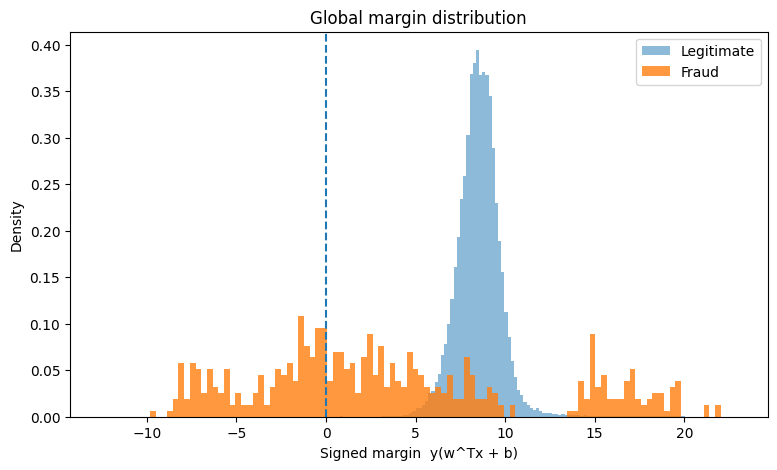

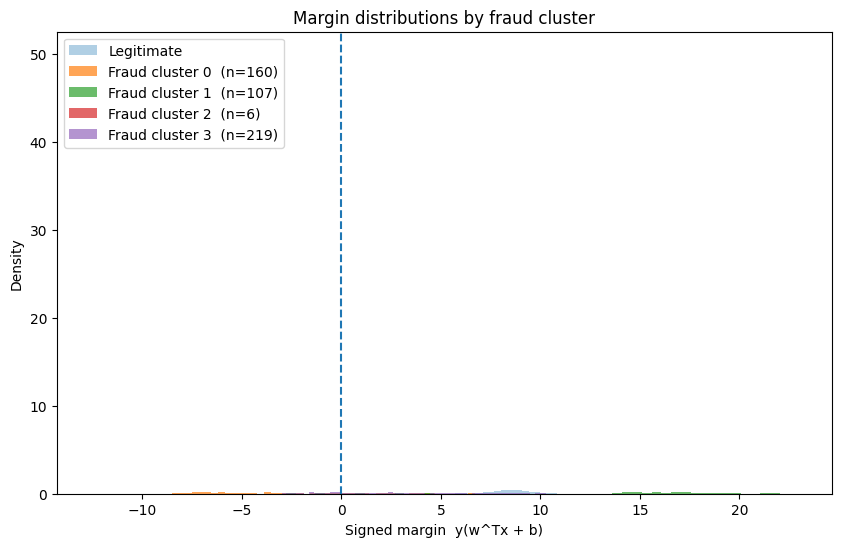

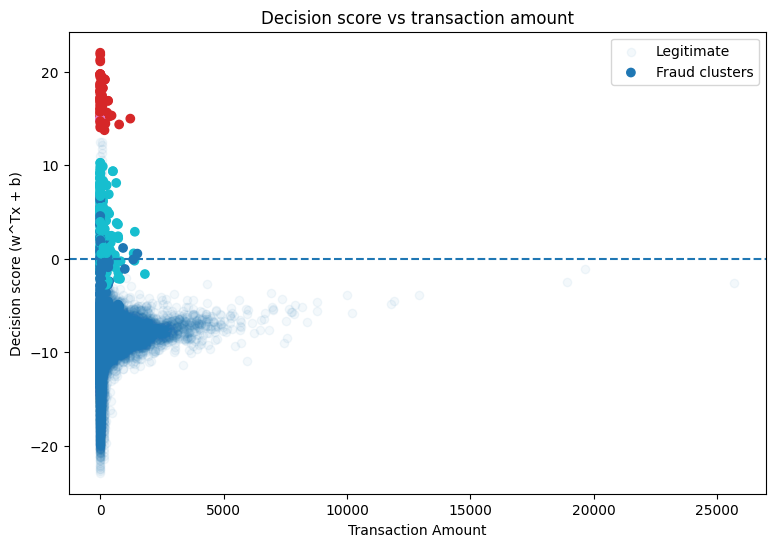

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# --------------------------------------------------
# 1 Load data
# --------------------------------------------------

dat = pd.read_csv('/home/maria/CrimeStats/data/creditcard.csv')

X = dat.drop(columns=["Class"]).values
y = dat["Class"].values

# convert labels to {-1,1}
y_signed = np.where(y == 1, 1, -1)

print("Total samples:", len(y))
print("Fraud cases:", np.sum(y == 1))
print("Legitimate:", np.sum(y == 0))

# --------------------------------------------------
# 2 Standardize features
# --------------------------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(X)

# --------------------------------------------------
# 3 Fit logistic regression (no train/test split)
# --------------------------------------------------

model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1
)

model.fit(X, y)

print("Model fitted.")

# --------------------------------------------------
# 4 Compute signed margins
# --------------------------------------------------

scores = model.decision_function(X)

margins = y_signed * scores

fraud_idx = y == 1
legit_idx = y == 0

fraud_margins = margins[fraud_idx]
legit_margins = margins[legit_idx]

print("Margins computed.")

# --------------------------------------------------
# 5 Cluster fraud transactions
# --------------------------------------------------

fraud_X = X[fraud_idx]

k = 4
kmeans = KMeans(n_clusters=k, random_state=0)

fraud_clusters = kmeans.fit_predict(fraud_X)

print("Fraud clustering complete.")

# --------------------------------------------------
# 6 Plot overall margin distribution
# --------------------------------------------------

plt.figure(figsize=(9,5))

plt.hist(
    legit_margins,
    bins=200,
    alpha=0.5,
    label="Legitimate",
    density=True
)

plt.hist(
    fraud_margins,
    bins=100,
    alpha=0.8,
    label="Fraud",
    density=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Signed margin  y(w^Tx + b)")
plt.ylabel("Density")
plt.title("Global margin distribution")
plt.legend()

plt.show()

# --------------------------------------------------
# 7 Plot margin distribution per fraud cluster
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    legit_margins,
    bins=200,
    alpha=0.35,
    label="Legitimate",
    density=True
)

for c in range(k):

    cluster_margins = fraud_margins[fraud_clusters == c]

    plt.hist(
        cluster_margins,
        bins=50,
        alpha=0.7,
        density=True,
        label=f"Fraud cluster {c}  (n={len(cluster_margins)})"
    )

plt.axvline(0, linestyle="--")

plt.xlabel("Signed margin  y(w^Tx + b)")
plt.ylabel("Density")

plt.title("Margin distributions by fraud cluster")

plt.legend()

plt.show()

# --------------------------------------------------
# 8 Scatter plot: decision score vs transaction amount
# --------------------------------------------------

plt.figure(figsize=(9,6))

amount = dat["Amount"].values

plt.scatter(
    amount[legit_idx],
    scores[legit_idx],
    alpha=0.05,
    label="Legitimate"
)

plt.scatter(
    amount[fraud_idx],
    scores[fraud_idx],
    c=fraud_clusters,
    cmap="tab10",
    label="Fraud clusters"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Transaction Amount")
plt.ylabel("Decision score (w^Tx + b)")
plt.title("Decision score vs transaction amount")

plt.legend()

plt.show()

Samples: 284807
Fraud: 492
Legitimate: 284315
Global model trained
Fraud clustering complete
Training model for fraud cluster 0
Training model for fraud cluster 1
Training model for fraud cluster 2
Training model for fraud cluster 3
Cluster models trained


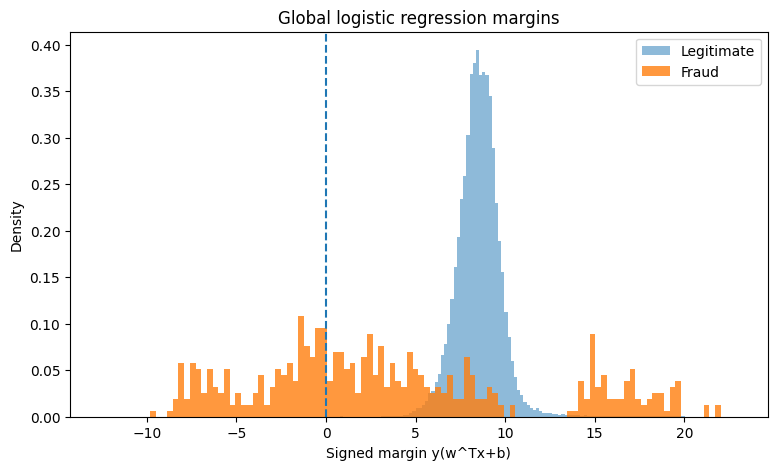

/home/maria/CrimeStats/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/home/maria/CrimeStats/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


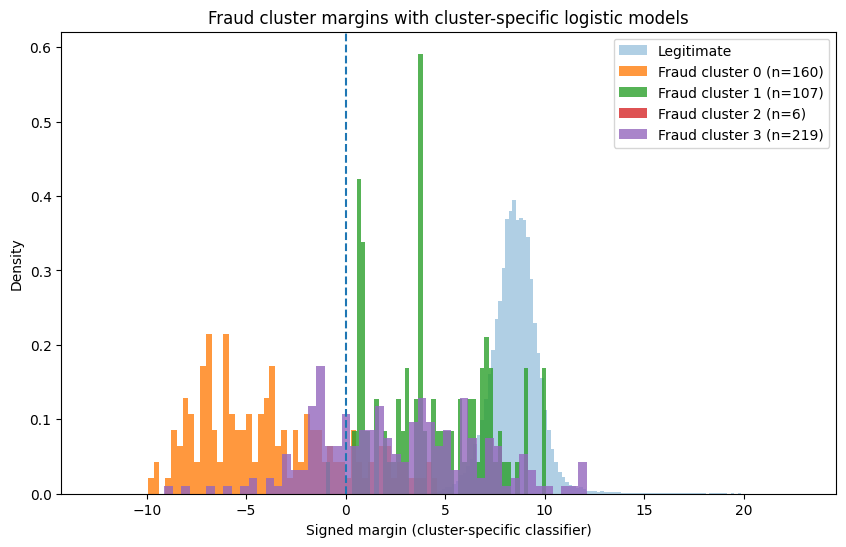

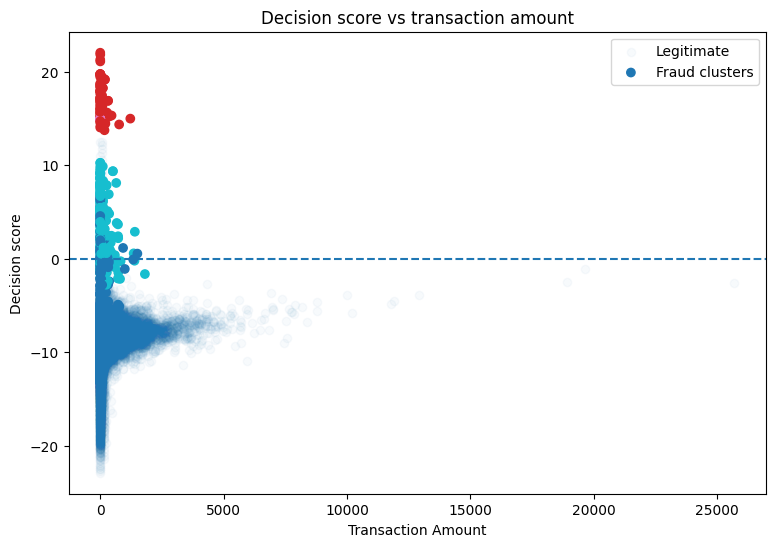

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# --------------------------------------------------
# 1 Load data
# --------------------------------------------------

dat = pd.read_csv('/home/maria/CrimeStats/data/creditcard.csv')

X = dat.drop(columns=["Class"]).values
y = dat["Class"].values

# convert labels to {-1,1}
y_signed = np.where(y == 1, 1, -1)

print("Samples:", len(y))
print("Fraud:", np.sum(y == 1))
print("Legitimate:", np.sum(y == 0))

# --------------------------------------------------
# 2 Standardize
# --------------------------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(X)

# --------------------------------------------------
# 3 Global logistic regression
# --------------------------------------------------

global_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1
)

global_model.fit(X, y)

global_scores = global_model.decision_function(X)
global_margins = y_signed * global_scores

print("Global model trained")

# --------------------------------------------------
# 4 Cluster fraud cases
# --------------------------------------------------

fraud_idx = y == 1
legit_idx = y == 0

fraud_X = X[fraud_idx]

k = 4

kmeans = KMeans(n_clusters=k, random_state=0)
fraud_clusters = kmeans.fit_predict(fraud_X)

print("Fraud clustering complete")

# --------------------------------------------------
# 5 Train cluster-specific logistic models
# --------------------------------------------------

cluster_models = []
cluster_margins = []

for c in range(k):

    print("Training model for fraud cluster", c)

    # fraud samples for this cluster
    cluster_mask = fraud_clusters == c
    fraud_cluster_X = fraud_X[cluster_mask]

    # combine with ALL legitimate transactions
    X_sub = np.vstack([X[legit_idx], fraud_cluster_X])

    y_sub = np.hstack([
        np.zeros(np.sum(legit_idx)),
        np.ones(len(fraud_cluster_X))
    ])

    y_sub_signed = np.where(y_sub == 1, 1, -1)

    model = LogisticRegression(
        max_iter=2000,
        solver="lbfgs"
    )

    model.fit(X_sub, y_sub)

    cluster_models.append(model)

    # compute margins for cluster fraud points
    scores = model.decision_function(fraud_cluster_X)
    margins = y_sub_signed[-len(fraud_cluster_X):] * scores

    cluster_margins.append(margins)

print("Cluster models trained")

# --------------------------------------------------
# 6 Plot global margins
# --------------------------------------------------

plt.figure(figsize=(9,5))

plt.hist(
    global_margins[legit_idx],
    bins=200,
    alpha=0.5,
    label="Legitimate",
    density=True
)

plt.hist(
    global_margins[fraud_idx],
    bins=100,
    alpha=0.8,
    label="Fraud",
    density=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Signed margin y(w^Tx+b)")
plt.ylabel("Density")
plt.title("Global logistic regression margins")

plt.legend()

plt.show()

# --------------------------------------------------
# 7 Plot cluster-specific margins
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    global_margins[legit_idx],
    bins=200,
    alpha=0.35,
    label="Legitimate",
    density=True
)

for c in range(k):

    plt.hist(
        cluster_margins[c],
        bins=50,
        alpha=0.8,
        density=True,
        label=f"Fraud cluster {c} (n={len(cluster_margins[c])})"
    )

plt.axvline(0, linestyle="--")

plt.xlabel("Signed margin (cluster-specific classifier)")
plt.ylabel("Density")

plt.title("Fraud cluster margins with cluster-specific logistic models")

plt.legend()

plt.show()

# --------------------------------------------------
# 8 Visualize decision scores vs transaction amount
# --------------------------------------------------

plt.figure(figsize=(9,6))

amount = dat["Amount"].values

plt.scatter(
    amount[legit_idx],
    global_scores[legit_idx],
    alpha=0.03,
    label="Legitimate"
)

fraud_scores = global_scores[fraud_idx]

plt.scatter(
    amount[fraud_idx],
    fraud_scores,
    c=fraud_clusters,
    cmap="tab10",
    label="Fraud clusters"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Transaction Amount")
plt.ylabel("Decision score")

plt.title("Decision score vs transaction amount")

plt.legend()

plt.show()